## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score
from transformers import AutoTokenizer, AutoModel
import torch
import gc
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from nltk.corpus import stopwords
import nltk

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Llama 3.1: 8B

In [2]:
%pip install -q "transformers>=4.46" accelerate bitsandbytes huggingface_hub 2>&1 | tail -2

Note: you may need to restart the kernel to use updated packages.


In [3]:
import os, time, gc
from pathlib import Path
from dataclasses import dataclass

# ── HF cache: prefer the class-shared dir on Tillicum, else default ──
# Setting HF_HOME *before* importing transformers ensures the library
# uses the shared cache for everything (hub downloads, tokenizers, ...).
_shared_cache = Path("/gpfs/projects/imt526a/huggingface")
if _shared_cache.exists():
    os.environ["HF_HOME"] = str(_shared_cache)
    HF_CACHE_DIR = str(_shared_cache)
else:
    HF_CACHE_DIR = None   # falls back to ~/.cache/huggingface

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

# ── Device ───────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

print(f"Device:    {DEVICE}")
print(f"HF cache:  {HF_CACHE_DIR or '~/.cache/huggingface (default)'}")
if DEVICE == "cuda":
    print(f"GPU:       {torch.cuda.get_device_name(0)}")
    print(f"VRAM:      {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# ── HF Hub auth check ────────────────────────────────────────────────────
# Unauthenticated requests are rate-limited on shared-IP environments.
# A class-wide token in /gpfs/projects/imt526a/huggingface/token would be
# picked up via HF_HOME automatically.
_hf_token = (os.environ.get("HF_TOKEN")
             or os.environ.get("HUGGING_FACE_HUB_TOKEN"))
if not _hf_token:
    for candidate in (Path(os.environ.get("HF_HOME", "")) / "token",
                      Path.home() / ".cache" / "huggingface" / "token"):
        if candidate.exists():
            _hf_token = candidate.read_text().strip()
            os.environ["HF_TOKEN"] = _hf_token
            break

print(f"HF auth:   {'token loaded' if _hf_token else 'anonymous (rate-limited)'}")


Device:    cuda
HF cache:  /gpfs/projects/imt526a/huggingface
GPU:       NVIDIA H200
VRAM:      150.1 GB
HF auth:   token loaded


- We use Llama 3.1 8B Instruct loaded with 4-bit quantization for memory-efficient inference/fine-tuning.

In [4]:
def cuda_mem_gb():
    if DEVICE != "cuda":
        return None
    return torch.cuda.memory_allocated() / 1e9

In [5]:
# ── Configuration ────────────────────────────────────────────────────────
MODEL_PRESET = "llama31"   

@dataclass
class Cfg:
    name: str
    hf_id: str
    short: str
    is_chat: bool

PRESETS = {
    "llama31": Cfg(
        "llama-3.1-8b",
        "meta-llama/Llama-3.1-8B-Instruct",
        "llama31",
        is_chat=True
    )
}

cfg = PRESETS[MODEL_PRESET]

print(f"Primary model: {cfg.name} ({cfg.hf_id})")

Primary model: llama-3.1-8b (meta-llama/Llama-3.1-8B-Instruct)


In [6]:
# ── PEFT / LoRA dependencies ─────────────────────────────────────────────
try:
    from peft import get_peft_model, LoraConfig, TaskType, prepare_model_for_kbit_training
    HAS_PEFT = True
    print("PEFT:      available")
except ImportError:
    HAS_PEFT = False
    print("PEFT:      not found -- pip install peft")

# ── Wire cfg into the names the QLoRA cell expects ───────────────────────
MODEL_NAME = cfg.hf_id        # "meta-llama/Llama-3.1-8B-Instruct"
device     = torch.device(DEVICE)

print(f"Model:     {MODEL_NAME}")
print(f"Device:    {device}")

PEFT:      available
Model:     meta-llama/Llama-3.1-8B-Instruct
Device:    cuda


In [7]:
def load_slm(hf_id, dtype=torch.float16, device_map="auto",
             quant_config=None, cache_dir=HF_CACHE_DIR):
    """Load an SLM in the specified dtype, optionally quantized.

    cache_dir defaults to the class-shared HF cache (set in §A) so model
    weights are downloaded once for the whole cohort."""
    tokenizer = AutoTokenizer.from_pretrained(
        hf_id, trust_remote_code=True, cache_dir=cache_dir)
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token = tokenizer.eos_token
    kwargs = dict(device_map=device_map, trust_remote_code=True,
                  cache_dir=cache_dir)
    if quant_config is not None:
        kwargs["quantization_config"] = quant_config
    else:
        kwargs["dtype"] = dtype
    model = AutoModelForCausalLM.from_pretrained(hf_id, **kwargs)
    model.eval()
    return model, tokenizer

In [8]:
# ── Load both SLMs in FP16 ───────────────────────────────────────────────
if DEVICE == "cuda":
    torch.cuda.reset_peak_memory_stats()
    base_mem = cuda_mem_gb()
    print(f"Baseline VRAM: {base_mem:.2f} GB")

print("Loading Llama-3.1-8B-Instruct...")
model_id, tokenizer = load_slm("meta-llama/Llama-3.1-8B-Instruct")
if DEVICE == "cuda":
    print(f"  VRAM after Llama-3.1-8B-Instruct:  {cuda_mem_gb():.2f} GB")

Baseline VRAM: 0.00 GB
Loading Llama-3.1-8B-Instruct...


Loading weights: 100%|██████████| 291/291 [00:04<00:00, 60.27it/s]


  VRAM after Llama-3.1-8B-Instruct:  16.06 GB


## Data Processing

### Test data / validation data
- Removing symbols, website URL

In [2]:
train_df = pd.read_csv('train_data.csv')
val_df = pd.read_csv('val_data.csv')

label = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']


def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"\n|\r|\t", " ", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_df['clean'] = train_df['comment_text'].apply(clean_text)
val_df['clean'] = val_df['comment_text'].apply(clean_text)


- transfer into binary column

In [3]:
label_cols = [
    "toxic",
    "severe_toxic",
    "obscene",
    "threat",
    "insult",
    "identity_hate"
]

# create binary labels
train_df["toxic_binary"] = train_df[label_cols].max(axis=1)
val_df["toxic_binary"] = val_df[label_cols].max(axis=1)

# keep only needed columns
train_df = train_df[[
    "id",
    "comment_text",
    "clean",
    "toxic_binary"
]]

val_df = val_df[[
    "id",
    "comment_text",
    "clean",
    "toxic_binary"
]]

train_df.head()

,id,comment_text,clean,toxic_binary
0,6ff62abb9f08ee3d,And more unfounded personal attacks by here a...,and more unfounded personal attacks by here at...,0
1,c438cd4e8073254a,Gilmore Girls \n\nI'm trying to figure out a f...,gilmore girls i m trying to figure out a few t...,0
2,2d7e5045431a4c70,What is the need of tagging..when we can impro...,what is the need of tagging when we can improv...,0
3,ddb267b1a581c366,"03:27, Jun 23, 2005 (UTC)",03 27 jun 23 2005 utc,0
4,53252a7f4f4bf87d,Inconsistencies \n\nThis article seems to pick...,inconsistencies this article seems to pick and...,0


In [4]:
val_df.head()

,id,comment_text,clean,toxic_binary
0,e5118b62193a58eb,"""\n""""oo9"""", if you have ANY actual evidence, s...",oo9 if you have any actual evidence show it yo...,0
1,39a8bb56027f9e30,It seems that AE defend anything - including v...,it seems that ae defend anything including van...,0
2,fb8159d9fe6c7098,Don Patch's Parents and Childhood ==\n\nI thin...,don patch s parents and childhood i think i kn...,0
3,e22073860027b589,IBX? \n\nI think this page is silly. I live in...,ibx i think this page is silly i live in choco...,0
4,9c7abe1474bab505,Sarah Palin's family \n\nWhy (or for that matt...,sarah palin s family why or for that matter ho...,0


### Test data
- move -1 value from test data, which indicates no value or result in the original dataset.

In [5]:
#load the dataset

test_df = pd.read_csv('test.csv')
test_df['clean'] = test_df['comment_text'].apply(clean_text)
test_df.head()

# Load files
test_labels = pd.read_csv('test_labels.csv')

# Drop -1 rows from test_labels
test_labels_valid = test_labels[test_labels['toxic'] != -1].reset_index(drop=True)

# Filter test.csv to only keep matching IDs
test_valid = test_df[test_df['id'].isin(test_labels_valid['id'])].reset_index(drop=True)

print(f"test_labels valid rows: {len(test_labels_valid)}")
print(f"test_scored rows: {len(test_valid)}")
# test_valid.head()

test_labels valid rows: 63978
test_scored rows: 63978


- transfer into binary column

In [6]:
test_eval_df = test_valid.merge(
    test_labels_valid, # y_true
    on="id"
)

label_cols = [
    "toxic",
    "severe_toxic",
    "obscene",
    "threat",
    "insult",
    "identity_hate"
]

# merge text + labels
test_eval_df = test_valid.merge(
    test_labels_valid,
    on="id"
)

# create binary label
test_eval_df["toxic_binary"] = (
    test_eval_df[label_cols].max(axis=1)
)

# test dataset
test_eval_df = test_eval_df[[
    "id",
    "comment_text",
    "clean",
    "toxic_binary"
]]

test_eval_df.head()

,id,comment_text,clean,toxic_binary
0,0001ea8717f6de06,Thank you for understanding. I think very high...,thank you for understanding i think very highl...,0
1,000247e83dcc1211,:Dear god this site is horrible.,dear god this site is horrible,0
2,0002f87b16116a7f,"""::: Somebody will invariably try to add Relig...",somebody will invariably try to add religion r...,0
3,0003e1cccfd5a40a,""" \n\n It says it right there that it IS a typ...",it says it right there that it is a type the t...,0
4,00059ace3e3e9a53,""" \n\n == Before adding a new product to the l...",before adding a new product to the list make s...,0


## TF-IDF

### Tune TF-IDF and Logistic Regression hyperparameters using validation set
- C (regularization strength)
- ngram_range (how many contextual phrases)

In [14]:
configs = [
    {"ngram_range": (1, 1), "C": 1.0},
    {"ngram_range": (1, 2), "C": 1.0},
    {"ngram_range": (1, 2), "C": 0.5},
    {"ngram_range": (1, 2), "C": 2.0},
    {'ngram_range': (1,2), 'C': 5.0},
    {'ngram_range': (1,2), 'C': 10.0},
    {'ngram_range': (1,3), 'C': 2.0}
]

best_score = -1
best_config = None
best_model = None
best_tfidf = None

for cfg in configs:
    tfidf = TfidfVectorizer(ngram_range=cfg["ngram_range"], max_features=50000)

    X_train = tfidf.fit_transform(train_df["clean"])
    X_val = tfidf.transform(val_df["clean"])

    model = LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        C=cfg["C"]
    )

    model.fit(X_train, train_df["toxic_binary"])

    val_pred = model.predict(X_val)
    val_true = val_df["toxic_binary"]

    val_macro_f1 = f1_score(val_true, val_pred, average="macro")

    print(cfg, "Validation Macro F1:", val_macro_f1)

    if val_macro_f1 > best_score:
        best_score = val_macro_f1
        best_config = cfg
        best_model = model
        best_tfidf = tfidf

print("Best config:", best_config)
print("Best validation Macro F1:", best_score)

{'ngram_range': (1, 1), 'C': 1.0} Validation Macro F1: 0.8558861346958775
{'ngram_range': (1, 2), 'C': 1.0} Validation Macro F1: 0.8545092440497596
{'ngram_range': (1, 2), 'C': 0.5} Validation Macro F1: 0.8437368075811771
{'ngram_range': (1, 2), 'C': 2.0} Validation Macro F1: 0.865003031823617
{'ngram_range': (1, 2), 'C': 5.0} Validation Macro F1: 0.8743932272654009
{'ngram_range': (1, 2), 'C': 10.0} Validation Macro F1: 0.8767496413793441
{'ngram_range': (1, 3), 'C': 2.0} Validation Macro F1: 0.8609574180731394
Best config: {'ngram_range': (1, 2), 'C': 10.0}
Best validation Macro F1: 0.8767496413793441


### Use test set to predict our result

In [15]:
X_test = best_tfidf.transform(test_eval_df["clean"])
y_true = test_eval_df["toxic_binary"]
y_pred = best_model.predict(X_test)

print("Macro F1:", f1_score(y_true, y_pred, average="macro"))
print("Toxic F1:", f1_score(y_true, y_pred, pos_label=1))
print("Toxic Precision:", precision_score(y_true, y_pred, pos_label=1))
print("Toxic Recall:", recall_score(y_true, y_pred, pos_label=1))

print(classification_report(y_true, y_pred, target_names=["Non-toxic", "Toxic"]))

Macro F1: 0.7785286231451061
Toxic F1: 0.6182147506650818
Toxic Precision: 0.47802871148459386
Toxic Recall: 0.8747397084734904
              precision    recall  f1-score   support

   Non-toxic       0.99      0.90      0.94     57735
       Toxic       0.48      0.87      0.62      6243

    accuracy                           0.89     63978
   macro avg       0.73      0.89      0.78     63978
weighted avg       0.94      0.89      0.91     63978



### Toxic comment distribution in our training dataset

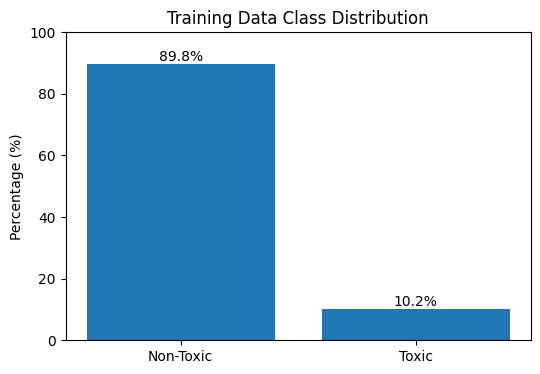

In [16]:
# Percentage distribution
train_percent = (
    train_df['toxic_binary']
    .value_counts(normalize=True)
    .sort_index() * 100
)

plt.figure(figsize=(6,4))

plt.bar(
    ['Non-Toxic', 'Toxic'],
    [
        train_percent.get(0, 0),
        train_percent.get(1, 0)
    ]
)

plt.ylabel('Percentage (%)')
plt.title('Training Data Class Distribution')

# show values on bars
for i, v in enumerate([
    train_percent.get(0, 0),
    train_percent.get(1, 0)
]):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center')

plt.ylim(0, 100)

plt.show()

- Heavily imbalanced data --> may lead to more non-toxic predictions

## Llama 3.1 8B Baseline

### Zero-shot

#### Zero-shot prompt function

In [14]:
def make_prompt(text, label=None):

#     prompt = f"""Classify the following comment as toxic or non-toxic.

# Return only one number:
# 1 = toxic
# 0 = non-toxic

# Comment:
# {text}

# Answer:
# """

    prompt = f"""Classify the following text as toxic or non-toxic.
    
Desired Format: a number, 1 = toxic, 0 = non-toxic

Input: 
{text}
Answer:
"""

    # add label during QLoRA training
    if label is not None:
        prompt += str(label)

    return prompt

In [15]:
from tqdm import tqdm

def zero_shot_predict(text, model, tokenizer):
    prompt = make_prompt(text)

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to(model_id.device)

    with torch.no_grad():
        outputs = model_id.generate(
            **inputs,
            max_new_tokens=5,
            do_sample=False,
            temperature=0.0,
            pad_token_id=tokenizer.eos_token_id
        )

    decoded = tokenizer.decode(outputs[0], skip_special_tokens=True)
    answer = decoded.split("Answer:")[-1].strip()

    if answer.startswith("1"):
        return 1
    elif answer.startswith("0"):
        return 0
    else:
        return 0
    
    # match = re.search(r"\b[01]\b", answer)
    
    if match:
        return int(match.group())
    else:
        return 0

#### validation prediction

In [16]:
# Use a small imbalanced validation sample for prompt testing
val_zero_df, _ = train_test_split(
    val_df,
    train_size=1000,
    stratify=val_df["toxic_binary"],
    random_state=42
)

val_zero_df = val_zero_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

# Check class distribution
print(val_zero_df["toxic_binary"].value_counts())

print(
    val_zero_df["toxic_binary"]
    .value_counts(normalize=True)
)

toxic_binary
0    899
1    101
Name: count, dtype: int64
toxic_binary
0    0.899
1    0.101
Name: proportion, dtype: float64


In [17]:
val_preds = []

for text in tqdm(val_zero_df["comment_text"]):
    pred = zero_shot_predict(text, model_id, tokenizer)
    val_preds.append(pred)

val_zero_df["zero_shot_pred"] = val_preds

  0%|          | 0/1000 [00:00<?, ?it/s][transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
100%|██████████| 1000/1000 [01:26<00:00, 11.51it/s]


#### Validation evaluation

In [18]:
y_true = val_zero_df["toxic_binary"]
y_pred = val_zero_df["zero_shot_pred"]

print("Validation Macro F1:",
      f1_score(y_true, y_pred, average="macro"))

print("Validation Toxic F1:",
      f1_score(y_true, y_pred, pos_label=1))

print("Validation Toxic Precision:",
      precision_score(y_true, y_pred, pos_label=1))

print("Validation Toxic Recall:",
      recall_score(y_true, y_pred, pos_label=1))

print(classification_report(
    y_true,
    y_pred,
    target_names=["Non-toxic", "Toxic"]
))

Validation Macro F1: 0.740787223607384
Validation Toxic F1: 0.5642633228840125
Validation Toxic Precision: 0.41284403669724773
Validation Toxic Recall: 0.8910891089108911
              precision    recall  f1-score   support

   Non-toxic       0.99      0.86      0.92       899
       Toxic       0.41      0.89      0.56       101

    accuracy                           0.86      1000
   macro avg       0.70      0.87      0.74      1000
weighted avg       0.93      0.86      0.88      1000



In [19]:
# if test data need to be reran
# os.remove("test_eval_zero_shot_results.csv")

#### test prediction

In [16]:
save_path = "test_eval_zero_shot_results.csv"

# ---------------------------------
# Load checkpoint if exists
# ---------------------------------

if os.path.exists(save_path):

    print("Loading existing checkpoint...")

    test_eval_df = pd.read_csv(save_path)
    completed_mask = test_eval_df["zero_shot_pred"].notna()
    start_idx = completed_mask.sum()
    print(f"Already completed: {start_idx} rows")

else:
    print("Starting new prediction run...")
    test_eval_df["zero_shot_pred"] = None
    start_idx = 0

# ---------------------------------
# Stop if already finished
# ---------------------------------

if start_idx == len(test_eval_df):
    print("All predictions already completed!")
else:
    # ---------------------------------
    # Continue prediction
    # ---------------------------------
    for i in tqdm(range(start_idx, len(test_eval_df))):

        text = test_eval_df.loc[i, "comment_text"]

        pred = zero_shot_predict(
            text,
            model_id,
            tokenizer
        )

        test_eval_df.loc[i, "zero_shot_pred"] = pred

        # Save checkpoint every 1000 rows
        if i % 1000 == 0:
            test_eval_df.to_csv(save_path, index=False)
            print(f"Saved checkpoint at row {i}")

    # Final save
    test_eval_df.to_csv(save_path, index=False)
    print("Finished all predictions!")

Loading existing checkpoint...
Already completed: 45001 rows


  0%|          | 0/18977 [00:00<?, ?it/s][transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
  5%|▌         | 1002/18977 [01:28<38:42,  7.74it/s]

Saved checkpoint at row 46000


 11%|█         | 2002/18977 [02:45<36:13,  7.81it/s]

Saved checkpoint at row 47000


...

Saved checkpoint at row 62000


 95%|█████████▍| 18002/18977 [22:17<02:03,  7.88it/s]

Saved checkpoint at row 63000


100%|██████████| 18977/18977 [23:27<00:00, 13.48it/s]


Finished all predictions!


#### test evaluation

In [17]:
y_true = test_eval_df["toxic_binary"]
y_pred = test_eval_df["zero_shot_pred"]

print("Test Macro F1:", f1_score(y_true, y_pred, average="macro"))
print("Test Toxic F1:", f1_score(y_true, y_pred, pos_label=1))
print("Test Toxic Precision:", precision_score(y_true, y_pred, pos_label=1))
print("Test Toxic Recall:", recall_score(y_true, y_pred, pos_label=1))

print(classification_report(
    y_true,
    y_pred,
    target_names=["Non-toxic", "Toxic"]
))

Test Macro F1: 0.6962973374439378
Test Toxic F1: 0.4903351141330743
Test Toxic Precision: 0.3518505610929114
Test Toxic Recall: 0.8085856158897966
              precision    recall  f1-score   support

   Non-toxic       0.98      0.84      0.90     57735
       Toxic       0.35      0.81      0.49      6243

    accuracy                           0.84     63978
   macro avg       0.66      0.82      0.70     63978
weighted avg       0.92      0.84      0.86     63978



### Qlora

In [20]:
# §M -- QLoRA backend detection.
# bitsandbytes (CUDA) integrates with transformers from_pretrained().
# mps-bitsandbytes uses its own quantize_model() after loading; it also
# ships its own BitsAndBytesConfig (not the transformers one).
HAS_BNB = False
BNB_FLAVOR = None
if HAS_PEFT:
    try:
        import bitsandbytes  # noqa: F401
        from transformers import BitsAndBytesConfig
        HAS_BNB = True
        BNB_FLAVOR = "bitsandbytes (CUDA)"
    except ImportError:
        try:
            # mps-bitsandbytes: load model first, then call quantize_model().
            # BitsAndBytesConfig and quantize_model come from this package, not transformers.
            from mps_bitsandbytes import BitsAndBytesConfig, quantize_model as bnb_quantize_model
            HAS_BNB = True
            BNB_FLAVOR = "mps-bitsandbytes (Apple Silicon)"
        except ImportError:
            pass

if HAS_BNB:
    print(f"QLoRA backend: {BNB_FLAVOR}")
else:
    print("Skipping §M -- install bitsandbytes (CUDA) or mps-bitsandbytes (Apple Silicon)")

QLoRA backend: bitsandbytes (CUDA)


In [21]:
if HAS_BNB:
    import warnings
    from peft import prepare_model_for_kbit_training
    warnings.filterwarnings("ignore", category=FutureWarning, module="bitsandbytes")

    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.bfloat16,
        bnb_4bit_use_double_quant=True,
    )

    print(f"Loading {MODEL_NAME} in 4-bit (NF4) via {BNB_FLAVOR}...")
    qmodel = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        quantization_config=bnb_config,
        device_map="auto",
        cache_dir=HF_CACHE_DIR,
        token=_hf_token,
    )
    qmodel = prepare_model_for_kbit_training(qmodel, use_gradient_checkpointing=False)

    qlora = get_peft_model(qmodel, LoraConfig(
        r=8, lora_alpha=16,
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],  # Llama-specific
        lora_dropout=0.05, bias="none",
        task_type=TaskType.CAUSAL_LM,
    ))
    qlora.print_trainable_parameters()

Loading meta-llama/Llama-3.1-8B-Instruct in 4-bit (NF4) via bitsandbytes (CUDA)...


Loading weights: 100%|██████████| 291/291 [00:05<00:00, 48.96it/s]


trainable params: 6,815,744 || all params: 8,037,076,992 || trainable%: 0.0848


In [22]:
from torch.utils.data import Dataset, DataLoader

class ToxicPromptDataset(Dataset):

    def __init__(self, df, tokenizer, max_length=256):

        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):

        return len(self.df)

    def __getitem__(self, i):

        row = self.df.iloc[i]

        text = row["comment_text"]
        label = str(row["toxic_binary"])

        prompt = make_prompt(text)

        full_text = make_prompt(text, label)

        full_enc = self.tokenizer(
            full_text,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )

        prompt_enc = self.tokenizer(
            prompt,
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )

        input_ids = full_enc["input_ids"].squeeze(0)

        attention_mask = full_enc["attention_mask"].squeeze(0)

        labels = input_ids.clone()

        # mask prompt tokens, train only on answer
        prompt_len = prompt_enc["input_ids"].shape[1]

        labels[:prompt_len] = -100

        # mask padding
        labels[attention_mask == 0] = -100

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": labels
        }

In [23]:
from sklearn.model_selection import train_test_split

if HAS_BNB:

    # -----------------------------
    # QLoRA training sample
    # -----------------------------

    toxic_train = train_df[train_df["toxic_binary"] == 1].sample(
        n=1000,
        random_state=42
    )

    non_toxic_train = train_df[train_df["toxic_binary"] == 0].sample(
        n=1000,
        random_state=42
    )

    fine_tune_df = pd.concat(
        [toxic_train, non_toxic_train]
    ).sample(
        frac=1,
        random_state=42
    ).reset_index(drop=True)


    # -----------------------------
    # QLoRA validation sample
    # -----------------------------

    qlora_val_df, _ = train_test_split(
        val_df,
        train_size=1000,
        stratify=val_df["toxic_binary"],
        random_state=42
    )

    qlora_val_df = qlora_val_df.reset_index(drop=True)


    # -----------------------------
    # DataLoaders
    # -----------------------------

    train_loader = DataLoader(
        ToxicPromptDataset(fine_tune_df, tokenizer),
        batch_size=4,
        shuffle=True
    )

    val_loader = DataLoader(
        ToxicPromptDataset(qlora_val_df, tokenizer),
        batch_size=4,
        shuffle=False
    )

    print(f"Train size: {len(fine_tune_df)}")
    print(f"Validation size: {len(qlora_val_df)}")
    print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Train size: 2000
Validation size: 1000
Train batches: 500 | Val batches: 250


#### training

In [24]:
import os
if os.path.exists("best_qlora_checkpoint"):
    print("Checkpoint found, skipping training!")
    print(os.listdir("best_qlora_checkpoint"))
else:
    if HAS_BNB:
        opt = torch.optim.AdamW(
            [p for p in qlora.parameters() if p.requires_grad],
            lr=5e-5
        )
    
        num_epochs = 2
        epoch_losses = {}
    
        best_val_loss = float("inf")
        best_epoch = None
    
        for epoch in range(1, num_epochs + 1):
            # ---------- Train ----------
            qlora.train()
            train_losses = []
    
            for step, batch in enumerate(train_loader):
                batch = {k: v.to(device) for k, v in batch.items()}
    
                opt.zero_grad(set_to_none=True)
    
                out = qlora(**batch)
                loss = out.loss
    
                loss.backward()
                opt.step()
    
                train_losses.append(loss.item())
    
                if step % 20 == 0:
                    print(f"Epoch {epoch} step {step:3d} train loss {loss.item():.4f}")
    
            avg_train_loss = sum(train_losses) / len(train_losses)
    
            # ---------- Validate ----------
            qlora.eval()
            val_losses = []
    
            with torch.no_grad():
                for batch in val_loader:
                    batch = {k: v.to(device) for k, v in batch.items()}
                    out = qlora(**batch)
                    val_losses.append(out.loss.item())
    
            avg_val_loss = sum(val_losses) / len(val_losses)
            epoch_losses[epoch] = avg_val_loss
    
            print(f"\nEpoch {epoch}")
            print(f"Train loss: {avg_train_loss:.4f}")
            print(f"Val CE loss: {avg_val_loss:.4f}")
    
            # ---------- Save only best checkpoint ----------
            if avg_val_loss < best_val_loss:
                best_val_loss = avg_val_loss
                best_epoch = epoch
    
                qlora.save_pretrained("best_qlora_checkpoint")
                tokenizer.save_pretrained("best_qlora_checkpoint")
    
                print(f"Saved new best checkpoint at epoch {epoch}")
    
            print()
    
        print("=" * 40)
        for ep, loss in epoch_losses.items():
            marker = " ◄ best" if ep == best_epoch else ""
            print(f"Epoch {ep} CE loss: {loss:.4f}{marker}")
        print("=" * 40)
    
        print(f"Best epoch: {best_epoch}")
        print(f"Best val CE loss: {best_val_loss:.4f}")
    
    else:
        print("bitsandbytes backend not available — skipping QLoRA training.")

Checkpoint found, skipping training!
['adapter_model.safetensors', 'tokenizer_config.json', 'chat_template.jinja', 'adapter_config.json', 'README.md', 'tokenizer.json']


#### Prediction

In [25]:
from peft import PeftModel

best_qlora = PeftModel.from_pretrained(
    qmodel,
    "best_qlora_checkpoint"
)
best_qlora.eval()

/gpfs/projects/imt526a/conda/envs/imt526a-jupyter-torch/lib/python3.14/site-packages/peft/tuners/tuners_utils.py:302: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): LlamaForCausalLM(
      (model): LlamaModel(
        (embed_tokens): Embedding(128256, 4096)
        (layers): ModuleList(
          (0-31): 32 x LlamaDecoderLayer(
            (self_attn): LlamaAttention(
              (q_proj): lora.Linear4bit(
                (base_layer): Linear4bit(in_features=4096, out_features=4096, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=4096, out_features=8, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=8, out_features=4096, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): lora.

In [26]:
import re

def qlora_predict(text, model, tokenizer):

    prompt = make_prompt(text)

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=256
    ).to(model.device)

    model.eval()

    with torch.no_grad():

        outputs = model.generate(
            **inputs,
            max_new_tokens=3,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )

    decoded = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    answer = decoded.split("Answer:")[-1].strip()

    # safer parsing
    match = re.search(r"\b[01]\b", answer)

    if match:
        return int(match.group())

    return 0

In [27]:
# if need to rerun the prediction

# if os.path.exists("qlora_predictions.csv"):
#     os.remove("qlora_predictions.csv")
#     print("CSV deleted.")
# else:
#     print("File does not exist.")

In [28]:
if os.path.exists("qlora_predictions.csv"):
    print("Already exists, loading from file!")
    qlora_val_df = pd.read_csv("qlora_predictions.csv")
else:
    qlora_preds = []
    
    tokenizer.padding_side = 'left'
    for text in tqdm(qlora_val_df["comment_text"]):
        pred = qlora_predict(text, best_qlora, tokenizer)
        qlora_preds.append(pred)
    
    qlora_val_df["qlora_pred"] = qlora_preds
    qlora_val_df.to_csv("qlora_predictions.csv", index=False)

Already exists, loading from file!


In [29]:
y_true = qlora_val_df["toxic_binary"]
y_pred = qlora_val_df["qlora_pred"]

print("Macro F1:", f1_score(y_true, y_pred, average="macro"))
print("Toxic F1:", f1_score(y_true, y_pred, pos_label=1))
print("Toxic Precision:", precision_score(y_true, y_pred, pos_label=1))
print("Toxic Recall:", recall_score(y_true, y_pred, pos_label=1))

print(classification_report(y_true, y_pred))

Macro F1: 0.7700164953686081
Toxic F1: 0.6081081081081081
Toxic Precision: 0.46153846153846156
Toxic Recall: 0.8910891089108911
              precision    recall  f1-score   support

           0       0.99      0.88      0.93       899
           1       0.46      0.89      0.61       101

    accuracy                           0.88      1000
   macro avg       0.72      0.89      0.77      1000
weighted avg       0.93      0.88      0.90      1000



#### Final Model Run

In [47]:
half = len(test_scored) // 2

part1 = test_valid.iloc[:half].reset_index(drop=True)
part2 = test_valid.iloc[half:].reset_index(drop=True)

part1.to_csv('test_run_part1.csv', index=False)
part2.to_csv('test_run_part2.csv', index=False)

print(f"Part 1: {len(part1)} rows → mei")
print(f"Part 2: {len(part2)} rows → vvn")

Part 1: 31989 rows → mei
Part 2: 31989 rows → vvn


#### test data 1

In [27]:
df = pd.read_csv('test_run_part1.csv')
df['clean'] = df['comment_text'].apply(clean_text)
df.head()

,id,comment_text,clean
0,0001ea8717f6de06,Thank you for understanding. I think very high...,thank you for understanding i think very highl...
1,000247e83dcc1211,:Dear god this site is horrible.,dear god this site is horrible
2,0002f87b16116a7f,"""::: Somebody will invariably try to add Relig...",somebody will invariably try to add religion r...
3,0003e1cccfd5a40a,""" \n\n It says it right there that it IS a typ...",it says it right there that it is a type the t...
4,00059ace3e3e9a53,""" \n\n == Before adding a new product to the l...",before adding a new product to the list make s...


In [28]:
import os

CHUNK_SIZE = 1000
output_file = 'test_part1_predictions.csv'

if os.path.exists(output_file):
    done_df = pd.read_csv(output_file)
    start_idx = len(done_df)
    print(f"Resuming from index {start_idx}")
else:
    start_idx = 0
    print("Starting fresh")

if start_idx < len(df):
    for start in tqdm(range(start_idx, len(df), CHUNK_SIZE)):
        chunk = df.iloc[start : start + CHUNK_SIZE]
        preds = [qlora_predict(text, best_qlora, tokenizer) for text in chunk["comment_text"]]
        chunk = chunk.copy()
        chunk["qlora_pred"] = preds
        chunk.to_csv(output_file, mode='a', header=(start == 0), index=False)

print("Done!")

Resuming from index 24000


100%|██████████| 8/8 [20:15<00:00, 151.91s/it]

Done!


#### test data 2

In [30]:
df_part2 = pd.read_csv('test_run_part2.csv')
df_part2['clean'] = df_part2['comment_text'].apply(clean_text)
df_part2.head()

,id,comment_text,clean
0,7fa82da2a247d215,""" \n\n == March 2011 == \n\n Please do not va...",march 2011 please do not vandalize pages as yo...
1,7fa91df080ff10b8,== How Alaska became US territory? == \n\n Act...,how alaska became us territory actually alaska...
2,7fa9fc8ef40b67ba,""" \n ::Actually, , it's not. The """"key descri...",actually it s not the key description as priva...
3,7fabc5f785a418a1,""" \n :It looks like it stalled. I'll look int...",it looks like it stalled i ll look into it online
4,7fac4c8e614f1bfc,:::::That solution ignores all the references ...,that solution ignores all the references to th...


In [31]:
import os

CHUNK_SIZE = 1000
output_file = 'test_part2_predictions.csv'

if os.path.exists(output_file):
    done_df = pd.read_csv(output_file)
    start_idx = len(done_df)
    print(f"Resuming from index {start_idx}")
else:
    start_idx = 0
    print("Starting fresh")

for start in tqdm(range(start_idx, len(df_part2), CHUNK_SIZE)):
    chunk = df_part2.iloc[start : start + CHUNK_SIZE]
    preds = [qlora_predict(text, best_qlora, tokenizer) for text in chunk["comment_text"]]
    chunk = chunk.copy()
    chunk["qlora_pred"] = preds
    chunk.to_csv(output_file, mode='a', header=(start == 0), index=False)

print("Done!")

Resuming from index 29000


100%|██████████| 3/3 [07:16<00:00, 145.62s/it]

Done!


In [7]:
part1 = pd.read_csv("test_part1_predictions.csv")
part2 = pd.read_csv("test_part2_predictions.csv")

qlora_test_df = pd.concat(
    [part1, part2],
    ignore_index=True
)

In [8]:
# conbine y_pred
cols_to_merge = ["id", "toxic_binary"]

qlora_test_df = qlora_test_df.merge(
    test_eval_df[cols_to_merge],
    on="id",
    how="left"
)

qlora_test_df.head()

,id,comment_text,clean,qlora_pred,toxic_binary
0,0001ea8717f6de06,Thank you for understanding. I think very high...,thank you for understanding i think very highl...,0,0
1,000247e83dcc1211,:Dear god this site is horrible.,dear god this site is horrible,1,0
2,0002f87b16116a7f,"""::: Somebody will invariably try to add Relig...",somebody will invariably try to add religion r...,0,0
3,0003e1cccfd5a40a,""" \n\n It says it right there that it IS a typ...",it says it right there that it is a type the t...,0,0
4,00059ace3e3e9a53,""" \n\n == Before adding a new product to the l...",before adding a new product to the list make s...,0,0


In [9]:
# Evaluation

y_true = qlora_test_df["toxic_binary"]
y_pred = qlora_test_df["qlora_pred"]

print("Macro F1:",
      f1_score(y_true, y_pred, average="macro"))
print("Toxic F1:",
      f1_score(y_true, y_pred, pos_label=1))
print("Toxic Precision:",
      precision_score(y_true, y_pred, pos_label=1))
print("Toxic Recall:",
      recall_score(y_true, y_pred, pos_label=1))
print(classification_report(
    y_true,
    y_pred,
    target_names=["Non-toxic", "Toxic"]
))

Macro F1: 0.7074865122982602
Toxic F1: 0.5136662651718706
Toxic Precision: 0.36133741771491884
Toxic Recall: 0.8880345987506006
              precision    recall  f1-score   support

   Non-toxic       0.99      0.83      0.90     57735
       Toxic       0.36      0.89      0.51      6243

    accuracy                           0.84     63978
   macro avg       0.67      0.86      0.71     63978
weighted avg       0.92      0.84      0.86     63978



### False Negative analysis

In [10]:
from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(
    qlora_test_df["toxic_binary"],
    qlora_test_df["qlora_pred"]
).ravel()

print("FP:", fp)
print("FN:", fn)

FP: 9799
FN: 699


- We detect it as non-toxic while it is actually toxic

In [11]:
fn_df = qlora_test_df[
    (qlora_test_df["toxic_binary"] == 1) &
    (qlora_test_df["qlora_pred"] == 0)
]

In [12]:
fn_df = fn_df[["clean"]].sample(50, random_state=42)

In [13]:
# fn_df.to_csv('fn_df.csv', index=False)

In [14]:
import re

text_col = "clean" 

patterns = {
    "profanity": [
        "fuck", "fucking", "shit", "ass", "damn", "crap", "bitch", "douche"
    ],
    "insult_words": [
        "stupid", "idiot", "dumb", "moron", "ridiculous", "crazy", "nonsense"
    ],
    "argumentative_words": [
        "wrong", "false", "lie", "lying", "attack", "bias", "biased",
        "block", "delete", "vandalism", "revert"
    ],
    "identity_terms": [
        "gay", "woman", "women", "man", "men", "black", "white",
        "asian", "indian", "muslim", "christian", "atheist"
    ],
    "quote_or_reported_speech": [
        "said", "called", "quote", "quoted", "told", "wrote"
    ],
    "internet_slang": [ 
        "lol", "lmao", "bro", "wtf", "trash", "suck", "sucks"
    ]
}

def count_pattern(text, word_list):
    text = str(text).lower()
    count = 0
    for word in word_list:
        count += len(re.findall(rf"\b{re.escape(word)}\b", text))
    return count

pattern_summary_fn = []

for category, words in patterns.items():
    counts = fn_df[text_col].apply(lambda x: count_pattern(x, words))
    pattern_summary_fn.append({
        "pattern": category,
        "num_comments_with_pattern": (counts > 0).sum(),
        "total_keyword_count": counts.sum()
    })

pattern_df_fn = pd.DataFrame(pattern_summary_fn).sort_values(
    "num_comments_with_pattern", ascending=False
)

pattern_df_fn

,pattern,num_comments_with_pattern,total_keyword_count
1,insult_words,19,20
0,profanity,9,10
2,argumentative_words,7,12
4,quote_or_reported_speech,5,6
5,internet_slang,4,5
3,identity_terms,2,3


### False Positive analysis

In [15]:
fp_df = qlora_test_df[
    (qlora_test_df["toxic_binary"] == 0) &
    (qlora_test_df["qlora_pred"] == 1)
]

In [16]:
fp_df = fp_df[["clean"]].sample(50, random_state=42)

In [17]:
# fp_df.to_csv('fp_df.csv', index=False)

In [18]:
fp_df.head()

,clean
3472,style margin 0 background color d0dde2 font fa...
5483,i m baffled by all the folks complaining about...
7324,he is knoiwn as a local hottie stunner
14694,list of dictators and omar bongo the recent re...
26378,you are a massive piece of crap lololol


In [19]:
import re

text_col = "clean" 

patterns = {
    "profanity": [
        "fuck", "fucking", "shit", "ass", "damn", "crap", "bitch", "douche"
    ],
    "insult_words": [
        "stupid", "idiot", "dumb", "moron", "ridiculous", "crazy", "nonsense"
    ],
    "argumentative_words": [
        "wrong", "false", "lie", "lying", "attack", "bias", "biased",
        "block", "delete", "vandalism", "revert"
    ],
    "identity_terms": [
        "gay", "woman", "women", "man", "men", "black", "white",
        "asian", "indian", "muslim", "christian", "atheist"
    ],
    "quote_or_reported_speech": [
        "said", "called", "quote", "quoted", "told", "wrote"
    ],
    "internet_slang": [ 
        "lol", "lmao", "bro", "wtf", "trash", "suck", "sucks"
    ]
}

def count_pattern(text, word_list):
    text = str(text).lower()
    count = 0
    for word in word_list:
        count += len(re.findall(rf"\b{re.escape(word)}\b", text))
    return count

pattern_summary = []

for category, words in patterns.items():
    counts = fp_df[text_col].apply(lambda x: count_pattern(x, words))
    pattern_summary.append({
        "pattern": category,
        "num_comments_with_pattern": (counts > 0).sum(),
        "total_keyword_count": counts.sum()
    })

pattern_df = pd.DataFrame(pattern_summary).sort_values(
    "num_comments_with_pattern", ascending=False
)

pattern_df

,pattern,num_comments_with_pattern,total_keyword_count
3,identity_terms,12,15
2,argumentative_words,11,25
4,quote_or_reported_speech,9,16
0,profanity,7,8
1,insult_words,4,5
5,internet_slang,1,1


### Data Visualization

In [20]:
fn_summary = pattern_df_fn[
    ["pattern", "num_comments_with_pattern"]
].rename(
    columns={"num_comments_with_pattern": "FN"}
)

fp_summary = pattern_df[
    ["pattern", "num_comments_with_pattern"]
].rename(
    columns={"num_comments_with_pattern": "FP"}
)

In [21]:
pattern_compare = fn_summary.merge(
    fp_summary,
    on="pattern",
    how="outer"
).fillna(0)

In [22]:
pattern_compare["FN"] = pattern_compare["FN"].astype(int)
pattern_compare["FP"] = pattern_compare["FP"].astype(int)

pattern_compare

,pattern,FN,FP
0,argumentative_words,7,11
1,identity_terms,2,12
2,insult_words,19,4
3,internet_slang,4,1
4,profanity,9,7
5,quote_or_reported_speech,5,9


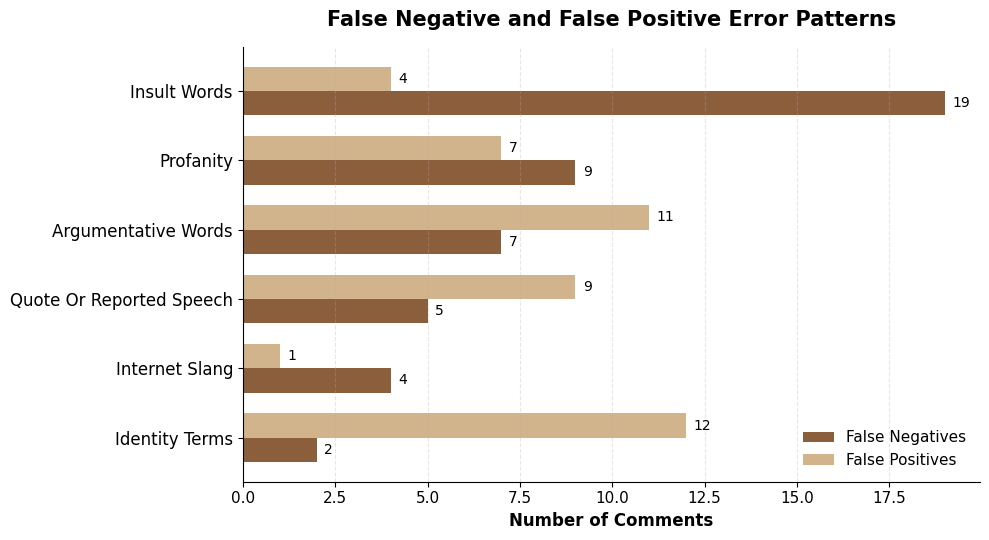

In [25]:
import matplotlib.pyplot as plt
pattern_compare = pattern_compare.rename(
    columns={"fn": "FN", "fp": "FP"}
)

plot_df = pattern_compare.copy()

plot_df["pattern"] = (
    plot_df["pattern"]
    .str.replace("_", " ")
    .str.title()
)

plot_df = plot_df.sort_values("FN", ascending=True)

# bar position
y = np.arange(len(plot_df))
bar_height = 0.35

# colors
fn_color = "#8B5E3C"   # dark brown
fp_color = "#D2B48C"   # light brown

plt.figure(figsize=(10, 5.5))

# FN bars
plt.barh(
    y - bar_height / 2,
    plot_df["FN"],
    height=bar_height,
    label="False Negatives",
    color=fn_color
)

# FP bars
plt.barh(
    y + bar_height / 2,
    plot_df["FP"],
    height=bar_height,
    label="False Positives",
    color=fp_color
)

# labels
plt.yticks(
    y,
    plot_df["pattern"],
    fontsize=12
)

plt.xticks(fontsize=11)

plt.xlabel(
    "Number of Comments",
    fontsize=12,
    fontweight="bold"
)

plt.title(
    "False Negative and False Positive Error Patterns",
    fontsize=15,
    fontweight="bold",
    pad=15
)

# add value labels
for i, v in enumerate(plot_df["FN"]):
    plt.text(
        v + 0.2,
        i - bar_height / 2,
        str(v),
        va="center",
        fontsize=10
    )

for i, v in enumerate(plot_df["FP"]):
    plt.text(
        v + 0.2,
        i + bar_height / 2,
        str(v),
        va="center",
        fontsize=10
    )

# grid
plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

# cleaner frame
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# legend
plt.legend(
    frameon=False,
    fontsize=11
)

plt.tight_layout()
plt.show()

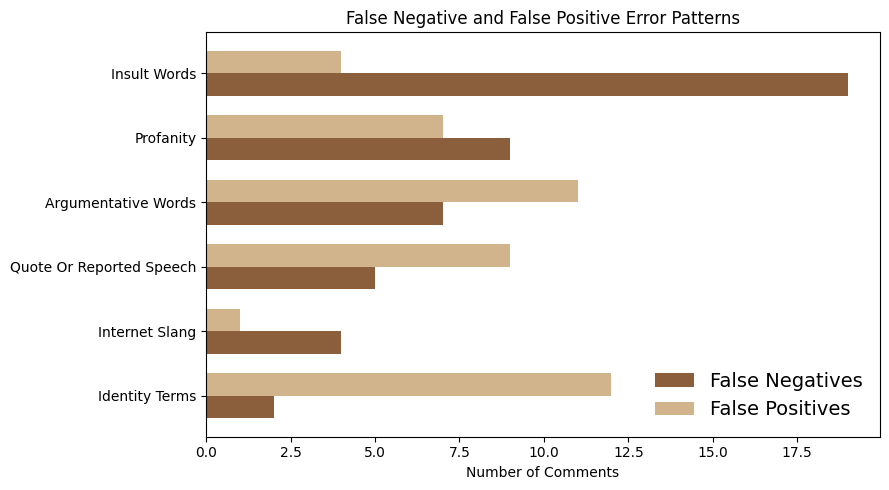

In [30]:
import matplotlib.pyplot as plt

pattern_compare = pattern_compare.rename(
    columns={"fn": "FN", "fp": "FP"}
)

plot_df = pattern_compare.copy()

plot_df["pattern"] = (
    plot_df["pattern"]
    .str.replace("_", " ")
    .str.title()
)

plot_df = plot_df.sort_values("FN", ascending=True)

# bar position
y = np.arange(len(plot_df))
bar_height = 0.35
  
fn_colors = [
    "#6B3E26" if p == "insult_words" else "#8B5E3C"
    for p in plot_df["pattern"]
]

fp_colors = [
    "#C49A6C" if p == "identity_terms" else "#D2B48C"
    for p in plot_df["pattern"]
]

plt.figure(figsize=(9, 5))

plt.barh(
    y - bar_height / 2,
    plot_df["FN"],
    height=bar_height,
    label="False Negatives",
    color=fn_color
)

plt.barh(
    y + bar_height / 2,
    plot_df["FP"],
    height=bar_height,
    label="False Positives",
    color=fp_color
)

plt.yticks(y, plot_df["pattern"])
plt.xlabel("Number of Comments")
plt.title("False Negative and False Positive Error Patterns")

plt.legend(
    frameon=False,
    fontsize=14,
    loc="lower right"
)

plt.tight_layout()
plt.show()

### Comment length analysis

In [27]:
qlora_test_df["length"] = qlora_test_df["clean"].str.split().str.len()

fn_df["length"] = fn_df["clean"].str.split().str.len()
fp_df["length"] = fp_df["clean"].str.split().str.len()

tp_df = qlora_test_df[
    (qlora_test_df["toxic_binary"] == 1) &
    (qlora_test_df["qlora_pred"] == 1)
]

tn_df = qlora_test_df[
    (qlora_test_df["toxic_binary"] == 0) &
    (qlora_test_df["qlora_pred"] == 0)
]

print("FN avg length:", fn_df["length"].mean())
print("FP avg length:", fp_df["length"].mean())
print("TP avg length:", tp_df["length"].mean())
print("TN avg length:", tn_df["length"].mean())

FN avg length: 36.14
FP avg length: 182.0612244897959
TP avg length: 43.11507936507937
TN avg length: 45.19401607184071
